In [1]:
import pandas as pd 
import numpy as np
from sklearn.decomposition import PCA
from pymer4.models import lmer
import patsy
from pymer4 import load_dataset,make_rfunc
import polars as pl
from tqdm.notebook import tqdm

# Development

In [27]:
data=pd.read_csv('/Users/jaileru/GitHub/batch-effects-dashboard/data/streamlit_sample_data.csv')
metadata=pd.read_csv('/Users/jaileru/GitHub/batch-effects-dashboard/data/streamlit_sample_metadata.csv')
data.set_index("sample_name",inplace=True)
metadata.set_index("sample_name",inplace=True)
D = data.copy()
M = metadata.copy()
D = D.fillna(D.min().min())
D_std = D.apply(lambda x: (x-x.mean(axis=0))/x.std(axis=0,ddof=0))
pca = PCA()  
pca_result = pca.fit_transform(D_std)

# Get components and explained variance
exp_var = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_.T  # shape: (n_features, n_components)

# Find number of PCs to keep
threshold = 0.50
cumsum = np.cumsum(exp_var)

# Method 1: Keep PCs until threshold is reached (inclusive)
pc_idx = np.argmax(cumsum >= threshold) + 1  # +1 to include the PC that crosses threshold

# Slice consistently
eigenvalues_kept = eigenvalues[:pc_idx]
eigenvectors_kept = eigenvectors[:, :pc_idx]  # Keep first pc_idx columns
pca_df = pd.DataFrame(pca_result[:, :pc_idx], 
                     index=D.index, 
                     columns=[f'PC{i+1}' for i in range(pc_idx)])

metadata['overall_injection_order'] = metadata.injection_order
metadata['injection_order'] = metadata.groupby('batch')['overall_injection_order'].rank(method='dense').astype(int)

pca_df['batch'] = metadata['batch']
pca_df['sample_type'] = metadata['sample_type']
pca_df['injection_order'] = metadata['injection_order']
pca_df['batch'] = pca_df['batch'].astype('category')
pca_df['sample_type'] = pca_df['sample_type'].astype('category')
pca_df['injection_order'] = pca_df['injection_order'].astype('category')
pca_df['overall_injection_order'] = metadata['overall_injection_order'].astype('category')
pca_df = pl.from_pandas(pca_df)

In [28]:
model1 = lmer("PC1 ~ (1|sample_type) + (1|batch)",data=pca_df,REML=True)
model2 = lmer("PC2 ~ (1|sample_type) + (1|batch)",data=pca_df,REML=True)

In [198]:
model1.fit(summary=True)
model2.fit()

In [4]:
var_comp = make_rfunc("""
                      function(model){
                      output <- VarCorr(model)
                      return(output)
                      }
                      """)
sigma = make_rfunc("""
                   function(model){
                   output <- sigma(model)^2
                   return(output)
                   }
                   """)

In [204]:
x1 = var_comp(model1.r_model)
y1 = sigma(model1.r_model)

x2 = var_comp(model2.r_model)
y2 = sigma(model2.r_model)

In [225]:
df1 = pd.DataFrame(np.hstack([np.array(x1).ravel(),np.array(y1)]),columns=['PC1'],index=['batch','sample_type','residuals']).T
df2 = pd.DataFrame(np.hstack([np.array(x2).ravel(),np.array(y2)]),columns=['PC2'],index=['batch','sample_type','residuals']).T
df = pd.concat([df1,df2])
df_std = df.div(df.sum(axis=1),axis='index')
df_std

,batch,sample_type,residuals
PC1,0.193487,0.684541,0.121972
PC2,0.160097,0.751643,0.088260


In [226]:
weight = eigenvalues / np.sum(eigenvalues)

In [227]:
idx = 0
for index, row in df_std.iterrows():
    df_std.loc[index,:] = df_std.loc[index,:] * weight[idx]
    idx += 1

In [233]:
pd.DataFrame(df_std.sum() / df_std.sum().sum())

,0
batch,0.186058
sample_type,0.699471
residuals,0.114471


In [234]:
df_std

,batch,sample_type,residuals
PC1,0.039987,0.141471,0.025207
PC2,0.009468,0.044454,0.005220


In [26]:
random_effects = pvca(data=data,metadata=metadata,explained_variance=.20)

In [20]:
df = pd.concat(lst,axis=1).T

In [22]:
df.sum() / df.sum().sum()

batch          0.231839
sample_type    0.503539
residuals      0.264622
dtype: float64

# PVCA Function

In [2]:
import pandas as pd 
import numpy as np
from sklearn.decomposition import PCA
from pymer4.models import lmer
import patsy
from pymer4 import load_dataset,make_rfunc
import polars as pl

data=pd.read_csv('/Users/jaileru/GitHub/batch-effects-dashboard/data/streamlit_sample_data.csv')
metadata=pd.read_csv('/Users/jaileru/GitHub/batch-effects-dashboard/data/streamlit_sample_metadata.csv')

data.set_index("sample_name",inplace=True)
metadata.set_index("sample_name",inplace=True)

def pvca(data,metadata,explained_variance=.50):
    D = data.copy()
    D = D.fillna(D.min().min())
    D_std = D.apply(lambda x: (x-x.mean(axis=0))/x.std(axis=0))
    pca = PCA()  
    pca_result = pca.fit_transform(D_std)
    exp_var = pca.explained_variance_ratio_
    eigenvalues = pca.explained_variance_
    eigenvectors = pca.components_.T
    cumsum = np.cumsum(exp_var)
    pc_idx = np.argmax(cumsum >= explained_variance) + 1
    eigenvalues_kept = eigenvalues[:pc_idx]
    eigenvectors_kept = eigenvectors[:,:pc_idx]
    pca_df = pd.DataFrame(pca_result[:, :pc_idx], 
                     index=D.index, 
                     columns=[f'PC{i+1}' for i in range(pc_idx)])
    pca_df['batch'] = metadata['batch'].astype('category')
    pca_df['sample_type'] = metadata['sample_type'].astype('category')
    pca_df = pl.from_pandas(pca_df)
    lst = []
    for PC in tqdm([x for x in pca_df.columns if x.startswith("PC")],desc='Applying LMM to PCs'):
        model = lmer(f"{PC} ~ (1|sample_type) + (1|batch)",data=pca_df,REML=True)
        model.fit()
        vca = var_comp(model.r_model)
        sig = sigma(model.r_model)
        lst.append(pd.DataFrame(np.hstack([np.array(vca).ravel(),np.array(sig)]),columns=[f'{PC}'],index=['batch','sample_type','residuals']))
    variance_components = pd.concat(lst,axis=1).T
    variance_components_std = variance_components.div(variance_components.sum(axis=1),axis='index')
    weights = eigenvalues[:len(eigenvalues_kept)] / np.sum(eigenvalues)
    variance_components_weighted = variance_components_std * weights[:,None]
    random_effects = variance_components_weighted.sum() / variance_components_weighted.sum().sum()
    return random_effects
var_comp = make_rfunc("""
                      function(model){
                      output <- VarCorr(model)
                      return(output)
                      }
                      """)
sigma = make_rfunc("""
                   function(model){
                   output <- sigma(model)^2
                   return(output)
                   }
                   """)


random_effects = pvca(data=data,metadata=metadata,explained_variance=.60)

Applying LMM to PCs:   0%|          | 0/38 [00:00<?, ?it/s]

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.

R messages: 
boundary (singular) fit: see help('isSingular')

Random effect variances not available. Returned R2 does not account for random effects.



/var/folders/dp/pf7gb4z168s3bmgs3xtm9rm00000gr/T/ipykernel_31906/3396891958.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(random_effects),x=random_effects.index,y=0,palette='bright')


Text(0.5, 0, 'Effects')

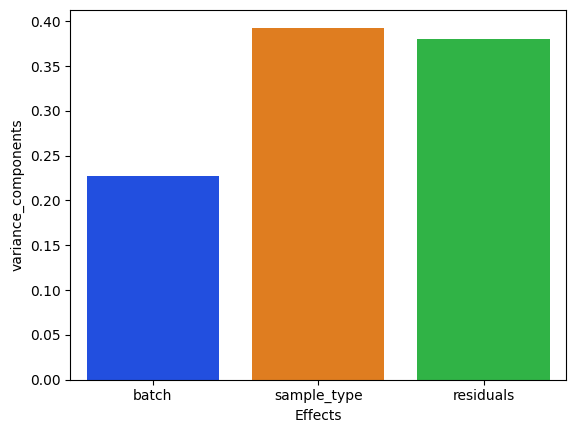

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.barplot(pd.DataFrame(random_effects),x=random_effects.index,y=0,palette='bright')
plt.ylabel('variance_components')
plt.xlabel('Effects')